In [1]:
import networkx as nx
import torch
import json
from pathlib import Path
from torch.utils.data import Subset
from torchtext.vocab import build_vocab_from_iterator
from torch_geometric.utils.convert import from_networkx
from torch_geometric.data import Data, HeteroData

from halide_gnn_cost_model.ast_parser import parse_ast, ASTFormatVisitor, ASTGraphVisitor

/Users/fangjun/Documents/stanford/cs224w/halide-gnn-cost-model/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Visualize a Pipeline DAG

In [2]:
# Load the pipeline DAG from a JSON file.
DAG_JSON_PATH = "../resources/pipelines/pipeline_1_0/dag.json"
with open(DAG_JSON_PATH, "r") as f:
    dag_data = json.load(f)

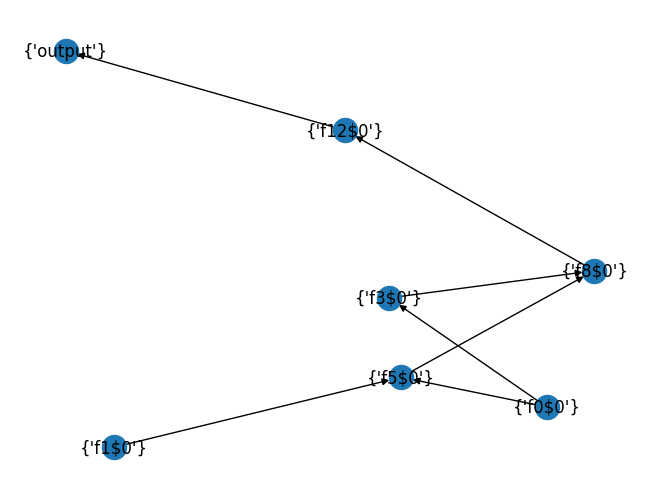

In [3]:
func_names = [func["name"] for func in dag_data]
dag = nx.DiGraph()
# Add function nodes.
for idx, func_name in enumerate(func_names):
    dag.add_node(idx, name={func_name})
# Add edges based on dependencies.
for idx, func in enumerate(dag_data):
    for dep in func["parents"]:
        dep_idx = func_names.index(dep)
        dag.add_edge(dep_idx, idx)
# Visualize the DAG.
labels = {n: dag.nodes[n]["name"] for n in dag.nodes()}
nx.draw(dag, labels=labels, pos=nx.spring_layout(dag, k=0.5, seed=42))

In [4]:
# Function name to DAG node ID mapping
func_name_to_id = {func["name"]: idx for idx, func in enumerate(dag_data)}
func_name_to_id

{'output': 0,
 'f12$0': 1,
 'f8$0': 2,
 'f5$0': 3,
 'f1$0': 4,
 'f3$0': 5,
 'f0$0': 6}

# Visualize the AST

In [5]:
AST_PATH = "../resources/pipelines/pipeline_1_0/ast.json"
with open(AST_PATH, "r") as f:
    ast_data = json.load(f)
ast_roots = parse_ast(ast_data)
ast_roots

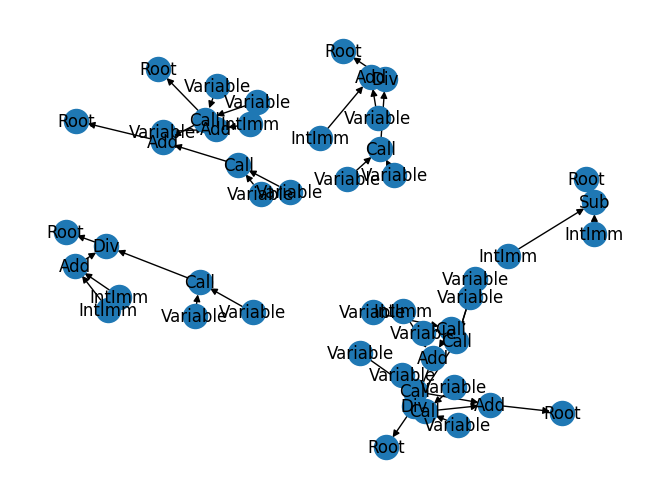

In [6]:
ast_graphs = []
for root in ast_roots:
    visitor = ASTGraphVisitor()
    root.accept(visitor)
    ast_graphs.append(visitor.get_graph())
ast_graph = nx.disjoint_union_all(ast_graphs)
labels = {n: ast_graph.nodes[n]["node_type"] for n in ast_graph.nodes()}
nx.draw(ast_graph, labels=labels, pos=nx.spring_layout(ast_graph, k=0.25, seed=42))

# Benchmark Result

In [7]:
# Pipeline Benchmark Result
BENCHMARK_PATH = "../resources/pipelines/pipeline_1_0/benchmark.json"
with open(BENCHMARK_PATH, "r") as f:
    benchmark_data = json.load(f)
y = torch.tensor([benchmark["real_time"] for benchmark in benchmark_data["benchmarks"]], dtype=torch.float)
y

tensor([  2.2974,   7.4328,  33.1797, 162.1127, 956.1634])

# Compose Heterogeneous Graph

In [8]:
data = HeteroData()
# Add DAG nodes
data["function"].x = torch.ones((dag.number_of_nodes(), 1), dtype=torch.float)
data["function", "called_by", "function"].edge_index = torch.tensor(list(dag.edges)).T.contiguous()

# Add AST nodes
node_types = [ast_node["node_type"] for _, ast_node in ast_graph.nodes(data=True)]
ast_vocab = build_vocab_from_iterator([node_types])
node_tokens = [ast_vocab[node_type] for node_type in node_types]
data["ast_node"].x = torch.tensor(node_tokens, dtype=torch.int).unsqueeze(-1)
data["ast_node", "child_of", "ast_node"].edge_index = torch.tensor(list(ast_graph.edges)).T.contiguous()

# Connect AST to corresponding function nodes
ast_to_func_edges = []
for ast_node_idx, ast_node in ast_graph.nodes(data=True):
    if ast_node["node_type"] != "Root":
        continue
    func_name = ast_node["function"]
    if func_name in func_name_to_id:
        func_idx = func_name_to_id[func_name]
        ast_to_func_edges.append((ast_node_idx, func_idx))
data["ast_node", "is_expr_of", "function"].edge_index = torch.tensor(ast_to_func_edges).T.contiguous()
data.y = y

data

1lines [00:00, 1733.18lines/s]


HeteroData(
  y=[5],
  function={ x=[7, 1] },
  ast_node={ x=[50, 1] },
  (function, called_by, function)={ edge_index=[2, 7] },
  (ast_node, child_of, ast_node)={ edge_index=[2, 43] },
  (ast_node, is_expr_of, function)={ edge_index=[2, 7] }
)

# Use Data Utils to Load Dataset

In [9]:
from halide_gnn_cost_model.data import load_pipeline, PipelineDataset

In [10]:
data = load_pipeline(Path("../resources/pipelines/pipeline_1_0"))
data

HeteroData(
  y=[5],
  function={ x=[7, 1] },
  (function, called_by, function)={ edge_index=[2, 7] }
)

In [11]:
dataset = PipelineDataset(Path("../resources/pipelines"))
len(dataset)

1002

In [12]:
for idx, data in enumerate(Subset(dataset, range(8))):
    print(f"Pipeline {idx} has {data['function'].x.shape[0]} functions.")

Pipeline 0 has 4 functions.
Pipeline 1 has 4 functions.
Pipeline 2 has 8 functions.
Pipeline 3 has 6 functions.
Pipeline 4 has 6 functions.
Pipeline 5 has 4 functions.
Pipeline 6 has 8 functions.
Pipeline 7 has 3 functions.
